# 20. 사는 쪽에서는 정체 품목이 살아나는가

## Overview

19번에서 정체 품목 셋(피마늘·깐마늘·생강)을 **출하 시점 결정에서 뺐습니다.**
모델이 늘 "내린다"고 확신해서 창고에 넣을 날이 연 0.0~5.9일뿐이었습니다.

**그런데 그건 파는 쪽 얘기입니다.** 사는 쪽에서는 "내린다"가 나쁜 신호가
아닙니다: **기다렸다 사면 싸게 삽니다.** 늘 "내린다"고 하는 품목이라면
오히려 구매자에게 맞을 수 있습니다.

13번에서 구매 시점(H2, +2.82%)이 출하 시점(H1, +2.85%)과 거의 같았는데,
그 뒤로 15~19번은 전부 파는 쪽만 다뤘습니다. 여기서 사는 쪽을 봅니다.

## 비용 구조가 다릅니다 — 이게 핵심입니다

| | 파는 쪽 (H1) | 사는 쪽 (H2) |
|---|---|---|
| 미룬다는 것 | 창고에 넣는다 | **그냥 안 산다** |
| 미룰 때 드는 돈 | **창고비** | 없음 |
| 제약 | 저장 가능 일수 | 그동안 쓸 물량이 있어야 함 |
| 지금 막힌 것 | **보관비 실측치가 없음** | 해당 없음 |

**지금 전체 분석의 최종 병목이 보관비인데, 사는 쪽에는 그 병목이 없습니다.**
저장성 제약도 없으니 19품목 전부가 후보입니다. 14번의 저장성 상충
(상관 -0.684)도 여기서는 적용되지 않습니다.

대신 다른 제약이 생깁니다: **구매를 미루려면 그동안 쓸 재고가 있어야 합니다.**
급식·식자재처럼 매일 써야 하는 곳은 마음대로 미룰 수 없습니다. 이 문서는
그 제약을 넣지 않으므로, 나오는 숫자는 **상한**입니다.

## 목차

1. 준비
2. 규칙과 가설
3. 품목별로 파는 쪽 vs 사는 쪽
4. 정체 품목 셋 집중
5. 운영 지표
6. 결론

## 1. 준비

15·17·19번과 똑같습니다. **학습은 19품목 전부**(19번에서 확정), 확신도 임계값은
0.20(17번에서 확정)입니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

H, THR, 정체선 = 7, 0.20, 40.0
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

정체율 = df.groupby("item").price_kg_avg.apply(lambda s: (s.diff() == 0).mean() * 100)
정체품목 = 정체율.index[정체율 >= 정체선].tolist()
잔류 = [i for i in items if i not in 정체품목]
print(f"정체 품목({정체선:.0f}% 이상): {정체품목}")

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    clf = HistGradientBoostingClassifier(
        categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.오름)
    t = te[["item", "price_date", "오름", "price_kg_avg", "미래가격"]].copy()
    t["오를확률"] = clf.predict_proba(te[FEATS])[:, 1]
    out.append(t)
r = pd.concat(out).reset_index(drop=True)
r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
r["확신도"] = (r.오를확률 - 0.5).abs()
기간연수 = (r.price_date.max() - r.price_date.min()).days / 365.25
print(f"준비 완료 ({time.time()-t0:.0f}초, {len(r):,}일, {기간연수:.2f}년)")
print(f"재현 확인: 적중률 {r.방향맞음.mean()*100:.1f}% (15번 62.8%)")

정체 품목(40% 이상): ['깐마늘(국산)', '생강', '피마늘']


준비 완료 (13초, 15,762일, 3.57년)
재현 확인: 적중률 62.8% (15번 62.8%)


## 2. 규칙과 가설

### 규칙 — 두 쪽은 정확히 거울입니다

| | 확신해서 행동하는 조건 | 그때 하는 일 | 아니면 |
|---|---|---|---|
| **파는 쪽 (H1)** | 오를 확률 > 0.5 **이고** 확신도 ≥ 0.20 | 7거래일 미뤄서 판다 | 오늘 판다 |
| **사는 쪽 (H2)** | 오를 확률 < 0.5 **이고** 확신도 ≥ 0.20 | 7거래일 기다렸다 산다 | 오늘 산다 |

**정체 품목은 모델이 늘 "내린다"고 확신하므로, 파는 쪽에서는 행동할 일이 거의
없고 사는 쪽에서는 자주 행동하게 됩니다.** 같은 예측의 앞뒤일 뿐입니다.

### 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 정체 품목은 사는 쪽에서 자주 행동한다 | 대기 비율이 잔류 품목보다 높음 |
| **H2** | 정체 품목은 사는 쪽에서 돈이 된다 | 덜 낸 돈 > 0 이고 파는 쪽보다 큼 |
| **H3** | 사는 쪽 전체가 파는 쪽만큼 쓸 만하다 | 덜 낸 돈이 더 받은 돈과 비슷 |

**H2 가 틀릴 수 있는 이유가 뚜렷합니다.** 정체 품목은 **가격이 거의 안
움직입니다**(피마늘은 89.8% 의 날에 전일과 같은 값). 방향을 맞혀도 벌 폭이
없을 수 있습니다. 14번에서 피마늘의 창고비 한도가 -0.74% 였던 것도 같은
이유였습니다: **"맞혀도 벌 게 없다"** 는 파는 쪽과 사는 쪽 모두에 걸립니다.

자주 행동하는 것(H1)과 돈이 되는 것(H2)은 **다른 얘기**입니다.

In [2]:
def 성과(s):
    # 파는 쪽: 오른다고 확신하면 미뤄 판다 / 사는 쪽: 내린다고 확신하면 기다렸다 산다
    오늘, 미래 = s.price_kg_avg.values, s.미래가격.values
    확신 = s.확신도.values >= THR
    팔기미룸 = (s.오를확률.values > 0.5) & 확신
    사기미룸 = (s.오를확률.values < 0.5) & 확신
    판값 = np.where(팔기미룸, 미래, 오늘)
    산값 = np.where(사기미룸, 미래, 오늘)
    n = s.item.nunique()
    return {
        "더 받은 돈 %": (판값.mean() / 오늘.mean() - 1) * 100,
        "덜 낸 돈 %": (1 - 산값.mean() / 오늘.mean()) * 100,
        "창고행 비율 %": 팔기미룸.mean() * 100,
        "대기 비율 %": 사기미룸.mean() * 100,
        "연 창고행(품목당)": 팔기미룸.sum() / 기간연수 / n,
        "연 대기(품목당)": 사기미룸.sum() / 기간연수 / n,
        "확신한 날 적중률 %": s.방향맞음[s.확신도 >= THR].mean() * 100,
    }


per = pd.DataFrame({it: 성과(s) for it, s in r.groupby("item")}).T
per["정체"] = [it in 정체품목 for it in per.index]
per["정체율 %"] = 정체율.reindex(per.index)
display(per.sort_values("덜 낸 돈 %", ascending=False).round(2))
print("'덜 낸 돈' 은 매입단가가 얼마나 내려갔나입니다: 양수가 좋습니다.")

,더 받은 돈 %,덜 낸 돈 %,창고행 비율 %,대기 비율 %,연 창고행(품목당),연 대기(품목당),확신한 날 적중률 %,정체,정체율 %
시금치,7.07,6.18,28.70,18.71,70.02,45.66,77.24,False,2.92
상추,4.35,3.79,21.47,19.52,52.38,47.62,80.67,False,2.33
깻잎,1.94,2.74,21.47,16.99,52.38,41.45,74.03,False,3.28
얼갈이배추,2.34,2.32,18.71,16.99,45.66,41.45,81.35,False,7.43
풋고추,2.93,2.30,23.08,15.38,56.30,37.53,76.12,False,2.19
배추,2.54,2.17,20.57,11.95,50.14,29.13,72.08,False,5.62
미나리,2.45,2.12,21.38,17.82,52.10,43.42,79.47,False,6.13
알배기배추,1.88,1.31,18.99,12.61,40.89,27.17,68.72,False,4.25
열무,2.16,1.29,19.17,13.09,46.78,31.93,75.09,False,6.12
브로콜리,2.43,1.26,28.33,9.63,56.02,19.05,76.12,False,2.95


'덜 낸 돈' 은 매입단가가 얼마나 내려갔나입니다: 양수가 좋습니다.


## 3. 품목별로 파는 쪽 vs 사는 쪽

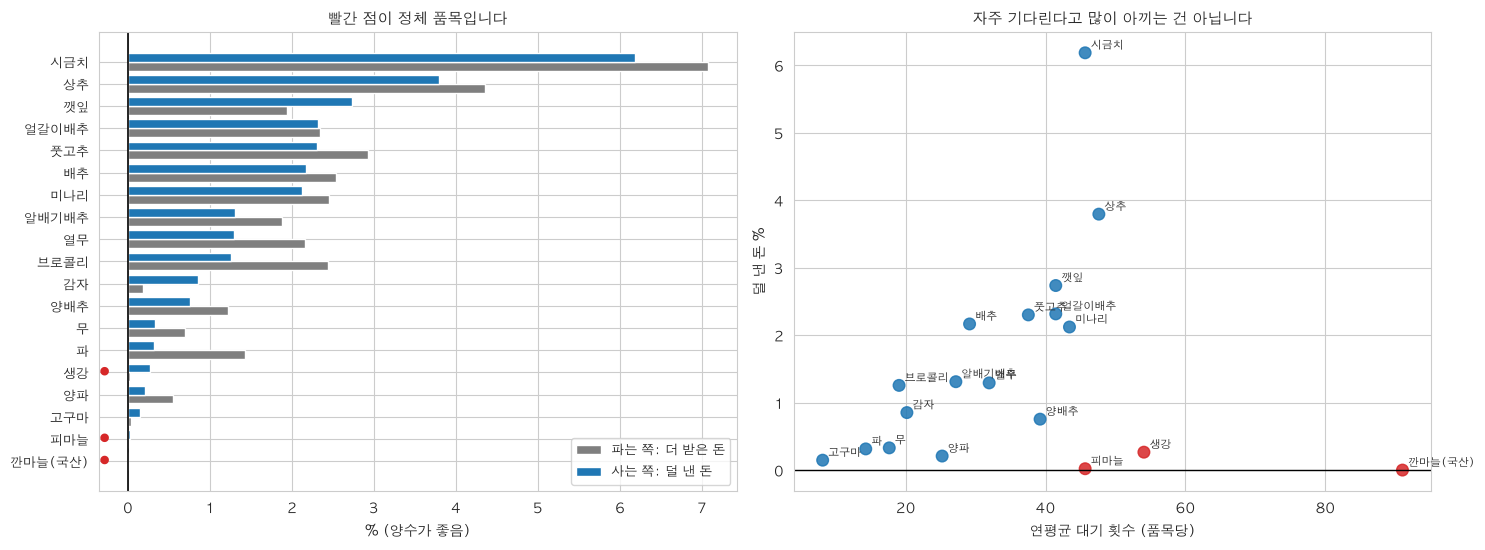

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

ax = axes[0]
p = per.sort_values("덜 낸 돈 %")
yy = np.arange(len(p))
ax.barh(yy - 0.2, p["더 받은 돈 %"], height=0.4, color="tab:gray",
        label="파는 쪽: 더 받은 돈")
ax.barh(yy + 0.2, p["덜 낸 돈 %"], height=0.4, color="tab:blue",
        label="사는 쪽: 덜 낸 돈")
for i, it in enumerate(p.index):
    if it in 정체품목:
        ax.text(-0.35, i, "●", color="tab:red", fontsize=11, va="center")
ax.axvline(0, color="black", lw=1.2)
ax.set_yticks(yy)
ax.set_yticklabels(p.index, fontsize=9)
ax.set_xlabel("% (양수가 좋음)")
ax.set_title("빨간 점이 정체 품목입니다", fontsize=11)
ax.legend(fontsize=9, loc="lower right")

ax = axes[1]
cols = ["tab:red" if v else "tab:blue" for v in per.정체]
ax.scatter(per["연 대기(품목당)"], per["덜 낸 돈 %"], s=70, c=cols, alpha=0.85)
for it, row in per.iterrows():
    ax.annotate(it, (row["연 대기(품목당)"], row["덜 낸 돈 %"]), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("연평균 대기 횟수 (품목당)")
ax.set_ylabel("덜 낸 돈 %")
ax.set_title("자주 기다린다고 많이 아끼는 건 아닙니다", fontsize=11)

plt.tight_layout()
plt.show()

## 4. 정체 품목 셋 집중

19번에서 뺀 셋이 사는 쪽에서 어떤지 봅니다.

In [4]:
rows = []
for label, sel in (("정체 품목 3", 정체품목), ("잔류 품목 16", 잔류),
                   ("전체 19품목", items)):
    s = r[r.item.isin(sel)]
    rows.append({"대상": label, "품목수": len(sel), **성과(s)})
비교 = pd.DataFrame(rows).set_index("대상")
display(비교.round(2))

print("\n정체 품목 셋 낱개")
display(per.loc[정체품목].round(2))
print("19번에서 뺀 근거는 '연 창고행' 열입니다. '연 대기' 와 비교해 보세요.")

,품목수,더 받은 돈 %,덜 낸 돈 %,창고행 비율 %,대기 비율 %,연 창고행(품목당),연 대기(품목당),확신한 날 적중률 %
대상,,,,,,,,
정체 품목 3,3,0.01,0.11,1.52,32.37,2.99,63.58,64.66
잔류 품목 16,16,2.70,2.44,19.19,12.78,45.88,30.57,73.35
전체 19품목,19,2.09,1.92,16.83,15.40,39.11,35.78,72.13



정체 품목 셋 낱개


,더 받은 돈 %,덜 낸 돈 %,창고행 비율 %,대기 비율 %,연 창고행(품목당),연 대기(품목당),확신한 날 적중률 %,정체,정체율 %
깐마늘(국산),-0.00,0.00,1.26,37.27,3.08,91.03,63.39,True,71.30
생강,0.03,0.27,2.41,22.18,5.88,54.06,61.68,True,58.21
피마늘,0.00,0.02,0.00,45.03,0.00,45.66,71.17,True,89.81


19번에서 뺀 근거는 '연 창고행' 열입니다. '연 대기' 와 비교해 보세요.


## 5. 운영 지표

**출하 전량을 오늘 팔면 1,000만 원**, **매입 전량을 오늘 사면 1,000만 원**으로
놓고 원 단위로 바꿉니다. 사는 쪽은 창고비가 없으니 **아낀 돈이 곧 남는 돈**입니다.

In [5]:
rows = []
for label, sel in (("정체 품목 3", 정체품목), ("잔류 품목 16", 잔류),
                   ("전체 19품목", items)):
    s = 성과(r[r.item.isin(sel)])
    rows.append({
        "대상": label,
        "사는 쪽: 아낀 돈 = 남는 돈 (만원)": 1000 * s["덜 낸 돈 %"] / 100,
        "파는 쪽: 번 돈 (만원)": 1000 * s["더 받은 돈 %"] / 100,
        "파는 쪽: 창고에 넣은 값 (만원)": 1000 * s["창고행 비율 %"] / 100,
        "파는 쪽: 창고비 한도 %": (s["더 받은 돈 %"] / s["창고행 비율 %"] * 100
                              if s["창고행 비율 %"] > 0 else np.nan),
    })
운영 = pd.DataFrame(rows).set_index("대상")
display(운영.round(1))
print("파는 쪽은 '번 돈' 에서 창고비를 빼야 남는 돈이 됩니다. 사는 쪽은 뺄 게 없습니다.")
print("다만 사는 쪽은 그동안 쓸 재고가 있어야 한다는 제약이 이 표에 안 들어갔습니다.")

# 창고비가 얼마를 넘으면 사는 쪽이 더 남는가
row = 운영.loc["잔류 품목 16"]
교차 = ((row["파는 쪽: 번 돈 (만원)"] - row["사는 쪽: 아낀 돈 = 남는 돈 (만원)"])
        / row["파는 쪽: 창고에 넣은 값 (만원)"] * 100)
print(f"\n잔류 16품목 기준, 창고비가 물건값의 {교차:.2f}% 를 넘으면 사는 쪽이 더 남습니다.")
print("(파는 쪽 남는 돈 = 번 돈 - 창고에 넣은 값 x 창고비율)")

,사는 쪽: 아낀 돈 = 남는 돈 (만원),파는 쪽: 번 돈 (만원),파는 쪽: 창고에 넣은 값 (만원),파는 쪽: 창고비 한도 %
대상,,,,
정체 품목 3,1.1,0.1,15.2,0.6
잔류 품목 16,24.4,27.0,191.9,14.0
전체 19품목,19.2,20.9,168.3,12.4


파는 쪽은 '번 돈' 에서 창고비를 빼야 남는 돈이 됩니다. 사는 쪽은 뺄 게 없습니다.
다만 사는 쪽은 그동안 쓸 재고가 있어야 한다는 제약이 이 표에 안 들어갔습니다.

잔류 16품목 기준, 창고비가 물건값의 1.31% 를 넘으면 사는 쪽이 더 남습니다.
(파는 쪽 남는 돈 = 번 돈 - 창고에 넣은 값 x 창고비율)


### 저장 못 하는 품목이 사는 쪽에서는 살아납니다

14번에서 가장 아팠던 대목이 **"1위 시금치(+7.44%)가 실행 불가"** 였습니다.
7일이면 상해서 미룰 수가 없었습니다.

**사는 쪽에는 그 제약이 없습니다.** 안 사고 기다리는 데는 저장이 필요 없습니다.

In [6]:
STORAGE = {
    "시금치": 7, "상추": 10, "배추": 30, "양배추": 50, "무": 45, "감자": 45,
    "양파": 165, "얼갈이배추": 10, "알배기배추": 20, "깻잎": 7, "미나리": 7,
    "열무": 7, "파": 7, "풋고추": 14, "브로콜리": 14, "고구마": 60,
    "생강": 90, "깐마늘(국산)": 30, "피마늘": 180,
}
불가품목 = [k for k, v in STORAGE.items() if v < 10]        # 14번의 '실행 불가'
가능품목 = [k for k, v in STORAGE.items() if v >= 10 and k in 잔류]

rows = []
for label, sel in (("파는 쪽 실행 불가 5품목", 불가품목),
                   ("파는 쪽 실행 가능 11품목", 가능품목),
                   ("정체 품목 3", 정체품목)):
    s = 성과(r[r.item.isin(sel)])
    rows.append({"대상": label, "품목수": len(sel),
                 "덜 낸 돈 %": s["덜 낸 돈 %"],
                 "더 받은 돈 %": s["더 받은 돈 %"],
                 "연 대기(품목당)": s["연 대기(품목당)"],
                 "사는 쪽 실행": "가능" if label != "정체 품목 3" else "가능(단 이득 없음)",
                 "파는 쪽 실행": "불가" if "불가" in label else "가능"})
저장 = pd.DataFrame(rows).set_index("대상")
display(저장.round(2))
print("파는 쪽에서 못 쓰던 엽채류가 사는 쪽에서는 그대로 쓸 수 있습니다.")
print("낱개로 보면 시금치가 양쪽 모두 1위입니다.")

,품목수,덜 낸 돈 %,더 받은 돈 %,연 대기(품목당),사는 쪽 실행,파는 쪽 실행
대상,,,,,,
파는 쪽 실행 불가 5품목,5,3.00,3.06,35.35,가능,불가
파는 쪽 실행 가능 11품목,11,1.89,2.32,28.39,가능,가능
정체 품목 3,3,0.11,0.01,63.58,가능(단 이득 없음),가능


파는 쪽에서 못 쓰던 엽채류가 사는 쪽에서는 그대로 쓸 수 있습니다.
낱개로 보면 시금치가 양쪽 모두 1위입니다.


## 6. 결론

### 한 줄 요약

**정체 품목은 사는 쪽에서도 못 씁니다.** 자주 기다리기는 하는데 아끼는 게
없습니다. 다만 **사는 쪽 자체는 파는 쪽만큼 좋고, 창고비가 안 든다는 점에서
오히려 낫습니다.**

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 정체 품목은 사는 쪽에서 자주 행동한다 | 대기 비율 **32.4%** vs 잔류 12.8% | **확인됨** |
| **H2** | 정체 품목은 사는 쪽에서 돈이 된다 | 덜 낸 돈 **0.11%** | **반증됨** |
| **H3** | 사는 쪽이 파는 쪽만큼 쓸 만하다 | 1.92% vs 2.09% (잔류 2.44% vs 2.70%) | **확인됨** |

### 정체 품목: 많이 기다리고 아무것도 못 법니다

| 품목 | 연 대기 횟수 | 덜 낸 돈 | 연 창고행 | 더 받은 돈 |
|---|---|---|---|---|
| 깐마늘(국산) | **91.0회** | **0.00%** | 3.1회 | -0.00% |
| 생강 | 54.1회 | 0.27% | 5.9회 | 0.03% |
| 피마늘 | 45.7회 | 0.02% | **0.0회** | 0.00% |

**예상했던 이유가 맞았습니다.** 깐마늘은 연 91회, 열흘에 세 번꼴로 "기다려라"
신호가 오는데 그렇게 아낀 돈이 **0.00%** 입니다. 가격이 안 움직이니 방향을
맞혀도 벌 폭이 없습니다(깐마늘 정체율 71.3%·피마늘 89.8%).

**H1 은 맞고 H2 는 틀렸다는 게 핵심입니다.** 자주 행동하는 것과 돈이 되는 것은
다릅니다. 신호 빈도만 보고 판단했으면 정반대 결론을 냈을 것입니다.

**19번의 제외 결정은 유지됩니다.** 다만 근거가 하나 늘었습니다: 파는 쪽에서
못 쓸 뿐 아니라 **사는 쪽에서도 못 씁니다.**

### 사는 쪽이 파는 쪽보다 나을 수 있습니다

1,000만 원어치 기준입니다.

| | 사는 쪽 | 파는 쪽 |
|---|---|---|
| 번(아낀) 돈 | **24.4만 원** | 27.0만 원 |
| 창고에 넣은 값 | 없음 | 191.9만 원 |
| 창고비 | **없음** | 물건값의 c% |
| **남는 돈** | **24.4만 원 확정** | 27.0 − 1.919c 만 원 |

**창고비가 물건값의 1.31% 를 넘으면 사는 쪽이 더 남습니다.** 파는 쪽이 앞서려면
7거래일 창고비가 1.31% 미만이어야 하는데, 대단히 빡빡한 조건입니다.

**보관비 실측치가 없어 파는 쪽 판단이 막혀 있는데, 사는 쪽에는 그 불확실성이
없습니다.** 지금 전체 분석의 최종 병목이 사는 쪽에서는 사라집니다.

⚠️ **다만 둘은 다른 주체입니다.** 농가가 "오늘은 사는 쪽으로 하겠다"고 고를 수
있는 게 아닙니다. 이 비교는 **이 도구를 누구에게 만들 것인가**를 정할 때
쓰는 숫자이지, 한 사람의 선택지가 아닙니다.

### 저장 못 하는 품목이 사는 쪽에서는 살아납니다

14번에서 가장 아팠던 대목이 **1위 시금치(+7.44%)가 실행 불가**였습니다.
7일이면 상해서 미룰 수가 없었습니다.

**사는 쪽에는 저장성 제약이 없습니다.** 안 사고 기다리는 데는 창고가 필요
없습니다.

| 묶음 | 품목수 | 사는 쪽 덜 낸 돈 | 파는 쪽 실행 |
|---|---|---|---|
| **파는 쪽 실행 불가 5품목** | 5 | **3.00%** | 불가 |
| 파는 쪽 실행 가능 11품목 | 11 | 1.89% | 가능 |
| 정체 품목 3 | 3 | 0.11% | 가능하나 무의미 |

**파는 쪽에서 못 쓰던 묶음이 사는 쪽에서는 가장 좋습니다**(3.00% vs 1.89%).
시금치는 사는 쪽에서도 **6.18%** 로 1위이고, 깻잎(2.74%)·미나리(2.12%)도
그대로 쓸 수 있습니다.

**14번의 저장성 상충(상관 -0.684)이 사는 쪽에서는 성립하지 않습니다.** 오히려
뒤집힙니다: 저장이 안 되는 품목일수록 사는 쪽에서 값을 합니다. 저장성이
막고 있던 게 무엇이었는지가 여기서 드러납니다.

### 한계

- **재고 제약을 안 넣었습니다.** 구매를 미루려면 그동안 쓸 물량이 있어야 합니다.
  급식·식자재처럼 매일 써야 하는 곳은 마음대로 못 미룹니다. **여기 숫자는
  상한입니다.**
- **조달 실패 위험도 안 넣었습니다.** 7거래일 뒤에 그 물건이 그 가격에 있다는
  보장이 없습니다. 파는 쪽의 감모·등급하락에 해당하는 위험입니다.
- **사는 쪽 확신도 임계값을 따로 안 골랐습니다.** 0.20 은 17번에서 파는 쪽
  기준으로 정한 값입니다. 사는 쪽 최적점은 다를 수 있습니다.
- **연 대기 횟수가 파는 쪽 창고행보다 적습니다**(30.6 vs 45.9회). 모델이
  "오른다"보다 "내린다"를 덜 확신한다는 뜻인데, 이유는 안 봤습니다.

### 다음

1. **사는 쪽을 정식 트랙으로 세울지 정합니다.** 지금까지 15~19번이 전부 파는
   쪽 기준이라, 사는 쪽으로 가려면 임계값·품목 선정을 다시 해야 합니다.
2. **재고 제약을 넣어 다시 잽니다.** "최대 N일까지만 미룰 수 있다"를 걸면
   상한이 얼마나 깎이는지 볼 수 있습니다.
3. **보관비 실측치**는 파는 쪽에만 필요합니다. 사는 쪽으로 간다면 그 병목이
   사라지므로, 우선순위가 바뀝니다.